In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import scipy.stats as ss

%matplotlib inline

# Simple Spatial SIR

In [34]:
def SimpleSpatialSIR(n, beta, gamma, tmax, start_infected_x, start_infected_y, rng):
    T = tmax

    grids = np.zeros((tmax+1,n,n))
    grids[0,start_infected_x,start_infected_y] = 1

    for t in range(tmax):
        infected_mask = np.zeros((n+2,n+2))
        infected_mask[1:-1,1:-1] = grids[t] == 1

        if (np.sum(infected_mask) == 0):
            T = t-1
            break

        infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                                infected_mask[1:-1,:-2] + # Left
                                infected_mask[2:,:-2] + # Lower left
                                infected_mask[2:,1:-1] + # Lower
                                infected_mask[2:,2:] + # Lower right
                                infected_mask[1:-1,2:] + # Right
                                infected_mask[:-2,2:] + # Upper right
                                infected_mask[:-2,1:-1] # Upper
                                )

        for i in range(n):
            for j in range(n):
                if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                    infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                    if (infect > 0):
                        grids[t+1,i,j] = 1
                if (grids[t,i,j] == 1):
                    recover = rng.binomial(n=1, p=gamma)
                    if (recover == 0):
                        grids[t+1,i,j] = 1
                    if (recover == 1):
                        grids[t+1:,i,j] = 2
    return grids, T

In [36]:
%matplotlib inline

beta = 0.5/7      # Infection prob
gamma = 0.3/7     # Recovery prob
tmax = 1000
n = 32
start_infected_x = [int(n/2),int(n/2),int(n/2)+1,int(n/2)+1]
start_infected_y = [int(n/2),int(n/2)+1,int(n/2),int(n/2)+1]
seed = 30
rng = np.random.default_rng(seed)
grids, T = SimpleSpatialSIR(n, beta, gamma, tmax, start_infected_x, start_infected_y, rng)

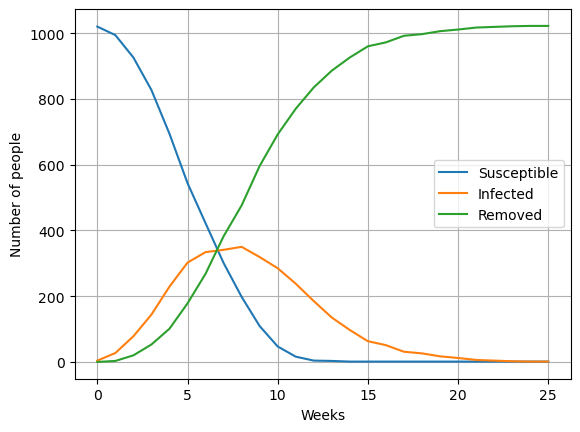

In [37]:
n_s = np.zeros(tmax+1)
n_i = np.zeros(tmax+1)
n_r = np.zeros(tmax+1)
for i in range(tmax+1):
    n_s[i] = np.sum(grids[i,:,:] == 0)
    n_i[i] = np.sum(grids[i,:,:] == 1)
    n_r[i] = np.sum(grids[i,:,:] == 2)

plt.plot(n_s[:T:7], label='Susceptible')
plt.plot(n_i[:T:7], label='Infected')
plt.plot(n_r[:T:7], label='Removed')

plt.legend()
plt.xlabel('Weeks')
plt.ylabel('Number of people')
plt.grid()
plt.show()

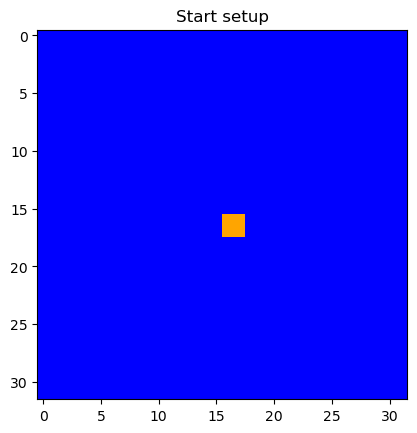

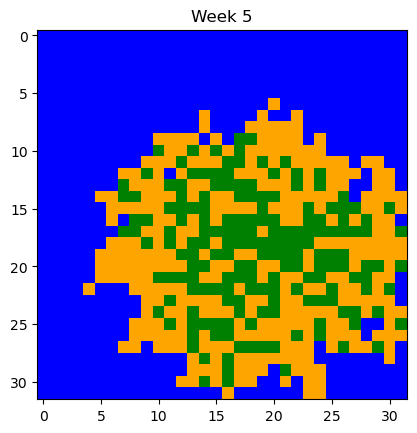

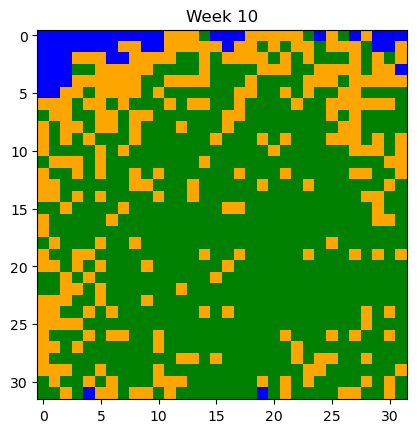

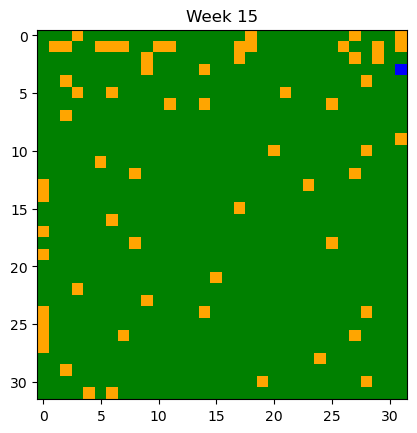

In [38]:
cmap = ListedColormap(['blue', 'orange', 'green'])

plt.imshow(grids[0], cmap=cmap, vmax=2)
plt.title('Start setup')
plt.show()

plt.imshow(grids[5*7], cmap=cmap, vmax=2)
plt.title('Week 5')
plt.show()

plt.imshow(grids[10*7], cmap=cmap, vmax=2)
plt.title('Week 10')
plt.show()

plt.imshow(grids[15*7], cmap=cmap, vmax=2)
plt.title('Week 15')
plt.show()

In [ ]:
stop

%matplotlib qt

fig = plt.figure()

im = plt.imshow(grids[0], animated=True, cmap=cmap)

def updatefig(frame):
    im = plt.imshow(grids[frame], animated=True, cmap=cmap)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=ts[:T], interval=200)

#ani.save(filename="pillow_example.gif", writer="pillow")

plt.show()

NameError: name 'stop' is not defined

In [54]:
sims = 100
Tmax = np.zeros(sims)
Tpeak = np.zeros(sims)
Ppeak = np.zeros(sims)
Rinf = np.zeros(sims)

beta = 0.5/7      # Infection prob
gamma = 0.3/7     # Recovery prob
tmax = 1000
n = 32

for i in range(sims):
    seed = i
    rng = np.random.default_rng(seed)
    start_infected_x = rng.choice(n,size=5)
    start_infected_y = rng.choice(n,size=5)
    grids, T = SimpleSpatialSIR(n, beta, gamma, tmax, start_infected_x, start_infected_y, rng)
    Tmax[i] = T/7
    infected = grids == 1
    sums = np.sum(infected, (1,2))
    Tpeak[i] = np.argmax(sums)/7
    Ppeak[i] = np.max(sums)/n*n
    Rinf[i] = np.sum(grids[-1] == 2)

In [55]:
# Confidence interval
alpha = 0.05
s = np.std(Tmax, ddof=1)
x_bar = np.mean(Tmax)
se = s/np.sqrt(sims)
t_crit = ss.t.ppf(1 - alpha/2,df=sims-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se


print(f"Tmax {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

Tmax 29.828571428571433
std: 4.2393353893497405
Confidence interval: 28.98739531430359, 30.669747542839275
Confidence interval witdh: 1.6823522285356844


In [56]:
# Confidence interval
alpha = 0.05
s = np.std(Tpeak, ddof=1)
x_bar = np.mean(Tpeak)
se = s/np.sqrt(sims)
t_crit = ss.t.ppf(1 - alpha/2,df=sims-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se


print(f"Tpeak {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

Tpeak 5.867142857142857
std: 0.9347403035966763
Confidence interval: 5.681670101577367, 6.0526156127083475
Confidence interval witdh: 0.37094551113098007


In [57]:
# Confidence interval
alpha = 0.05
s = np.std(Ppeak, ddof=1)
x_bar = np.mean(Ppeak)
se = s/np.sqrt(sims)
t_crit = ss.t.ppf(1 - alpha/2,df=sims-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se


print(f"Ppeak {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

Ppeak 415.5
std: 50.94332362755911
Confidence interval: 405.3917393692004, 425.6082606307996
Confidence interval witdh: 20.216521261599155


In [58]:
# Confidence interval
alpha = 0.05
s = np.std(Rinf, ddof=1)
x_bar = np.mean(Rinf)
se = s/np.sqrt(sims)
t_crit = ss.t.ppf(1 - alpha/2,df=sims-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se


print(f"Rinf {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

Rinf 1022.29
std: 1.9811995142215018
Confidence interval: 1021.8968870339561, 1022.6831129660438
Confidence interval witdh: 0.7862259320877456


# Wall test

In [59]:
beta = 0.5/7      # Infection prob
gamma = 0.3/7     # Recovery prob
tmax = 1000
n = 32
start_infected_x = [0,0,1,1]
start_infected_y = [0,1,0,1]
seed = 30
rng = np.random.default_rng(seed)
T = tmax

grids = np.zeros((tmax+1,n,n))
grids[0,start_infected_x,start_infected_y] = 1

grids[:,int(n/2),:int(n/2)] = 3

for t in range(tmax):
    infected_mask = np.zeros((n+2,n+2))
    infected_mask[1:-1,1:-1] = grids[t] == 1

    if (np.sum(infected_mask) == 0):
        T = t-1
        break

    infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                            infected_mask[1:-1,:-2] + # Left
                            infected_mask[2:,:-2] + # Lower left
                            infected_mask[2:,1:-1] + # Lower
                            infected_mask[2:,2:] + # Lower right
                            infected_mask[1:-1,2:] + # Right
                            infected_mask[:-2,2:] + # Upper right
                            infected_mask[:-2,1:-1] # Upper
                            )

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                if (infect > 0):
                    grids[t+1,i,j] = 1
            if (grids[t,i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                if (recover == 0):
                    grids[t+1,i,j] = 1
                if (recover == 1):
                    grids[t+1:,i,j] = 2

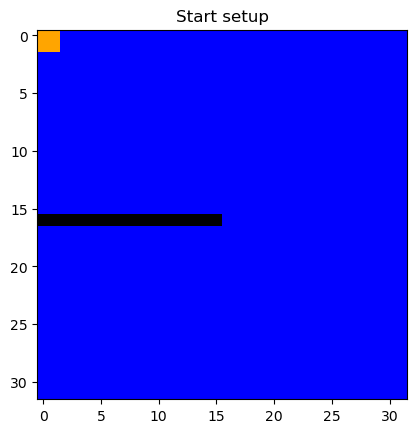

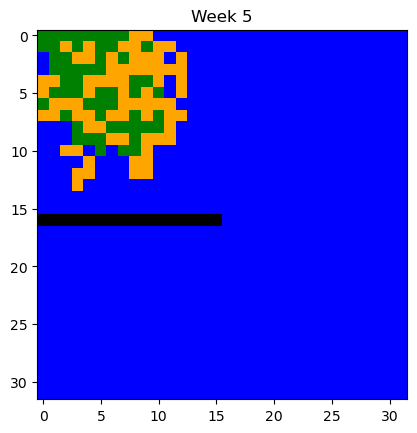

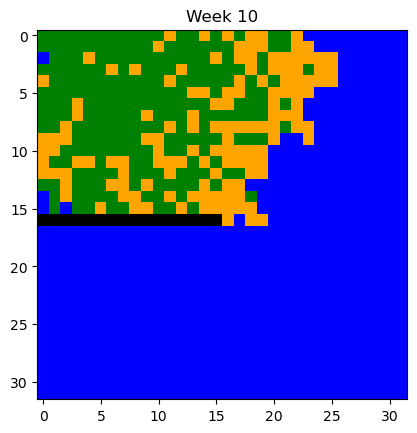

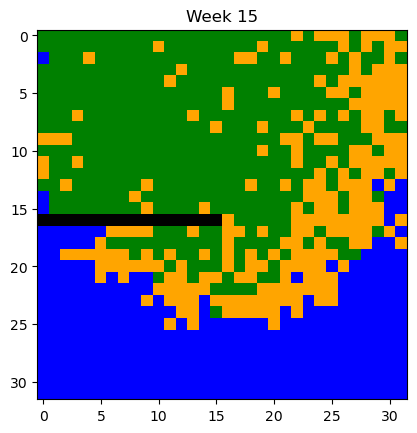

In [62]:
cmap = ListedColormap(['blue', 'orange', 'green', 'black'])

plt.imshow(grids[0], cmap=cmap, vmax=3)
plt.title('Start setup')
plt.show()

plt.imshow(grids[5*7], cmap=cmap, vmax=3)
plt.title('Week 5')
plt.show()

plt.imshow(grids[10*7], cmap=cmap, vmax=3)
plt.title('Week 10')
plt.show()

plt.imshow(grids[15*7], cmap=cmap, vmax=3)
plt.title('Week 15')
plt.show()

# Random spread

In [8]:
%matplotlib inline

In [7]:
# Parameters
n = 100
N = n**2

#beta = 0.5      # Infection prob
#gamma = 0.3     # Recovery prob
#d = 0.005

beta = 0.3/7
gamma = 0.5/7
d = 0

prob = 0.01

tmax = 1000
T = tmax
ts = np.arange(0,tmax+1,1)

grids = np.zeros((tmax+1,n,n))


#grids[0,0,0] = 1
#grids[0,0,-1] = 1
#grids[0,-1,0] = 1
#grids[0,-1,-1] = 1

grids[0,int(n/2):int(n/2)+2,int(n/2):int(n/2)+2] = 1

#grids[0,int(n/2):int(n/2)+5,int(n/2):int(n/2)+5] = 1

#grids[:,16,0:16] = 4

rng = np.random.default_rng(30)

for t in range(tmax):
    infected_mask = np.zeros((n+2,n+2))
    infected_mask[1:-1,1:-1] = grids[t] == 1

    if (np.sum(infected_mask) == 0):
        T = t-1
        break

    infected_neighbours = (infected_mask[:-2,:-2] + # Upper left
                            infected_mask[1:-1,:-2] + # Left
                            infected_mask[2:,:-2] + # Lower left
                            infected_mask[2:,1:-1] + # Lower
                            infected_mask[2:,2:] + # Lower right
                            infected_mask[1:-1,2:] + # Right
                            infected_mask[:-2,2:] + # Upper right
                            infected_mask[:-2,1:-1] # Upper
                            )
    

    for i in range(n):
        for j in range(n):
            if (grids[t,i,j] == 0 and infected_neighbours[i,j] > 0):
                infect = rng.binomial(n=int(infected_neighbours[i,j]), p=beta)
                if (infect > 0):
                    grids[t+1,i,j] = 1
            if (grids[t,i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                die = rng.binomial(n=1, p=d)
                if (recover == 0):
                    grids[t+1,i,j] = 1
                if (recover == 1 and die == 0):
                    grids[t+1:,i,j] = 2
                #if (recover == 0 and die == 1):
                #    grids[t+1:,i,j] = 3

    for k in range(int(np.sum(infected_mask))):
        random_infect = rng.choice(a=2, size=1, p=[1-prob, prob])
        if (random_infect == 0):
            continue
        if (random_infect == 1):
            x = rng.choice(n)
            y = rng.choice(n)
            if (grids[t+1,x,y] == 0):
                grids[t+1,x,y] = 1




            #infected = False
            #while (infected == False):
            #    x = rng.choice(n)
            #    y = rng.choice(n)
            #    if (grids[t+1,x,y] == 0):
            #        grids[t+1,x,y] = 1
            #        infected = True

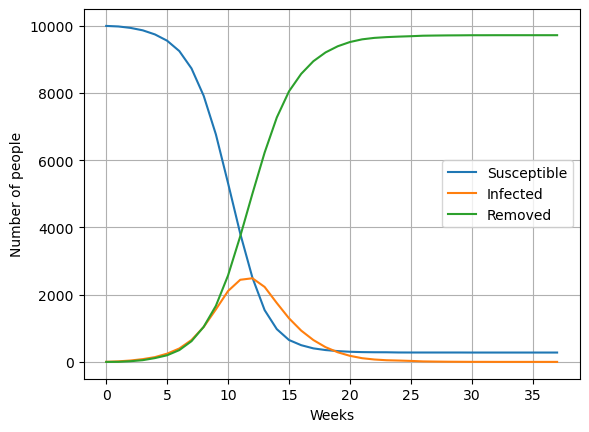

In [9]:
n_s = np.zeros(tmax+1)
n_i = np.zeros(tmax+1)
n_r = np.zeros(tmax+1)
n_d = np.zeros(tmax+1)
for i in range(tmax+1):
    n_s[i] = np.sum(grids[i,:,:] == 0)
    n_i[i] = np.sum(grids[i,:,:] == 1)
    n_r[i] = np.sum(grids[i,:,:] == 2)
    n_d[i] = np.sum(grids[i,:,:] == 3)

plt.plot(n_s[:T:7], label='Susceptible')
plt.plot(n_i[:T:7], label='Infected')
plt.plot(n_r[:T:7], label='Removed')
#plt.plot(n_d[:T], label='Dead')

plt.legend()
plt.xlabel('Weeks')
plt.ylabel('Number of people')
plt.grid()
plt.show()

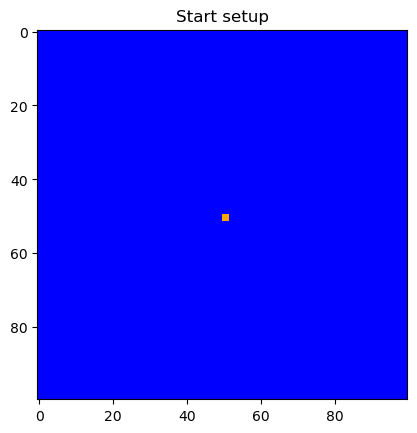

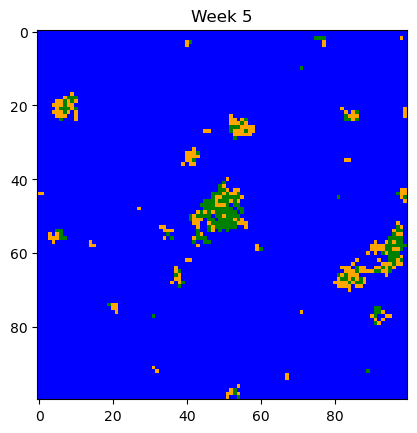

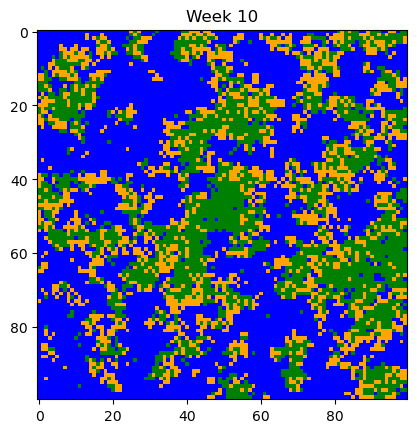

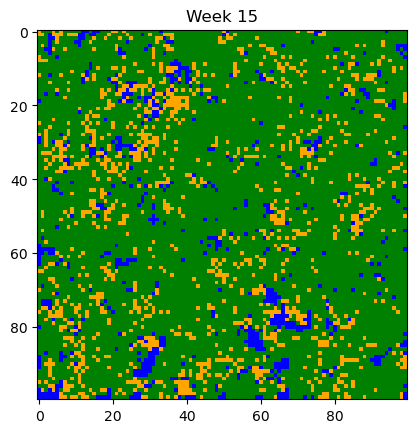

In [10]:
cmap = ListedColormap(['blue', 'orange', 'green'])

plt.imshow(grids[0], cmap=cmap, vmax=2)
plt.title('Start setup')
plt.show()

plt.imshow(grids[5*7], cmap=cmap, vmax=2)
plt.title('Week 5')
plt.show()

plt.imshow(grids[10*7], cmap=cmap, vmax=2)
plt.title('Week 10')
plt.show()

plt.imshow(grids[15*7], cmap=cmap, vmax=2)
plt.title('Week 15')
plt.show()

In [ ]:
stop

%matplotlib qt

fig = plt.figure()

im = plt.imshow(grids[0], animated=True, cmap=cmap)

def updatefig(frame):
    im = plt.imshow(grids[frame], animated=True, cmap=cmap)
    return im,

ani = animation.FuncAnimation(fig, updatefig, frames=ts[:T], interval=200)

#plt.colorbar()

#ani.save(filename="pillow_example.gif", writer="pillow")

plt.show()